# UK Wind Generation Forecast Analysis
**Dataset:** BMRS WINDFOR + FUELHH : January 2024  
**Horizon:** 24h ahead (day-ahead forecast model)

## Objective
1. Characterise the error profile of the WINDFOR forecast model
2. Recommend a reliable MW baseline for grid planning using bootstrapped confidence intervals

Data is fetched live from the Wind Forecast Monitor API which joins actuals (FUELHH) with forecasts (WINDFOR) and pre-computes error fields.

In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100
print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
API_URL = "https://wind-app.onrender.com/api/analysis"
print(f"Fetching data from {API_URL}")
r = requests.get(API_URL, timeout=120)
r.raise_for_status()

df = pd.DataFrame(r.json()["dataPoints"])
print(f"Loaded {len(df)} data points")
print(f"\nColumns: {list(df.columns)}")
print(f"\nFirst row:\n{df.iloc[0]}")

Fetching data from https://wind-app.onrender.com/api/analysis
Loaded 744 data points

Columns: ['time', 'actual', 'forecast', 'error', 'errorPct']

First row:
time        2024-01-01T00:00:00.000Z
actual                         10624
forecast                       10950
error                            326
errorPct                        3.07
Name: 0, dtype: object


In [3]:
df["time"]=pd.to_datetime(df["time"], utc=True)
df["hour"]=df["time"].dt.hour
df["date"]= df["time"].dt.date
df["abs_error"]= df["error"].abs()

print(f"Shape: {df.shape}")
print(f"Nulls: {df.isnull().sum().sum()}")
print(f"Date range: {df['time'].min()} → {df['time'].max()}")
print(f"\nSample:\n{df[['time','actual','forecast','error','abs_error']].head()}")

Shape: (744, 8)
Nulls: 0
Date range: 2024-01-01 00:00:00+00:00 → 2024-01-31 23:00:00+00:00

Sample:
                       time  actual  forecast  error  abs_error
0 2024-01-01 00:00:00+00:00   10624     10950    326        326
1 2024-01-01 01:00:00+00:00   11221     11077   -144        144
2 2024-01-01 02:00:00+00:00   11336     11232   -104        104
3 2024-01-01 03:00:00+00:00   11440     11347    -93         93
4 2024-01-01 04:00:00+00:00   11853     11609   -244        244


## Basic Error Statistics

In [4]:
mae= df["abs_error"].mean()
median = df["abs_error"].median()
p99= df["abs_error"].quantile(0.99)
bias= df["error"].mean()
rmse= np.sqrt((df["error"]**2).mean())

stats_summary = pd.DataFrame({
    "Metric": ["MAE", "Median Absolute Error", "P99 Error", "Mean Bias", "RMSE"],
    "Value (MW)": [round(mae), round(median), round(p99), round(bias), round(rmse)],
    "Interpretation": [
        "average miss per hour",
        "typical miss (robust to outliers)",
        "worst 1% of misses",
        "+ = over-forecast, - = under-forecast",
        "penalises large errors more than MAE"
    ]
})
stats_summary

,Metric,Value (MW),Interpretation
0,MAE,2000,average miss per hour
1,Median Absolute Error,1717,typical miss (robust to outliers)
2,P99 Error,7016,worst 1% of misses
3,Mean Bias,1253,"+ = over-forecast, - = under-forecast"
4,RMSE,2610,penalises large errors more than MAE


## Analysis 1: Does Forecast Error Scale With Generation Magnitude?
The hypothesis is that errors are not uniform which means that the model may perform well at moderate wind levels but become increasingly unreliable as generation increases. This is called heteroscedasticity and has direct operational implications: high-wind hours are exactly when grid operators are counting on wind to carry significant load.

Mean abs error below 6,000 MW:687 MW
Mean abs error above 12,000 MW:3048 MW
Error growth factor: 4.44x


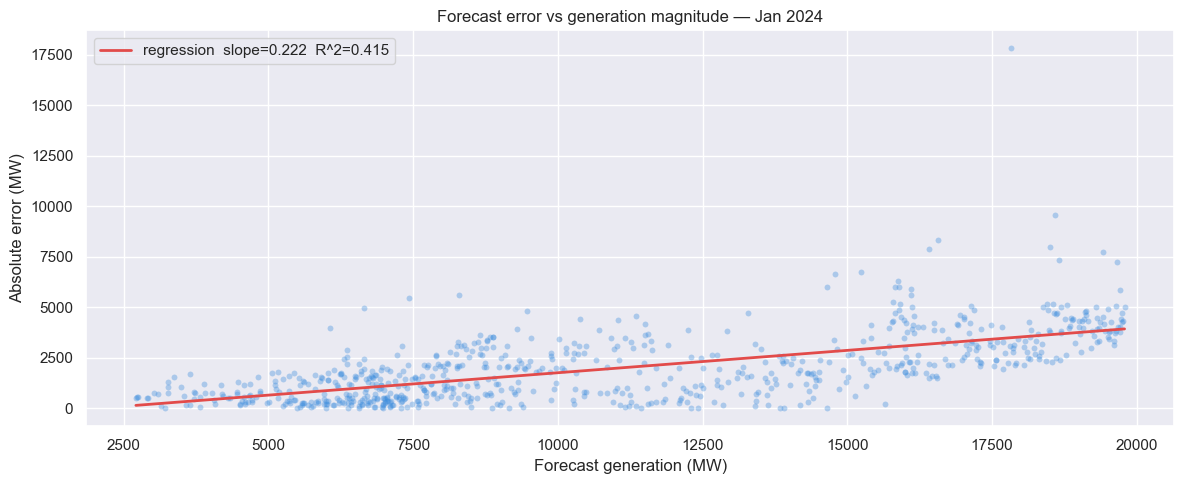

In [5]:
slope, intercept, r_value, p_value, std_err = stats.linregress(
    df["forecast"], df["abs_error"]
)
fig, ax = plt.subplots()
ax.scatter(df["forecast"], df["abs_error"],
           alpha=0.35, s=18, color="#378ADD", linewidths=0)
x_line = np.linspace(df["forecast"].min(), df["forecast"].max(), 200)
ax.plot(x_line, intercept + slope * x_line,
        color="#E24B4A", linewidth=2,
        label=f"regression  slope={slope:.3f}  R^2={r_value**2:.3f}")
ax.set_xlabel("Forecast generation (MW)")
ax.set_ylabel("Absolute error (MW)")
ax.set_title("Forecast error vs generation magnitude — Jan 2024")
ax.legend()

low_band=df[df["forecast"] <6000]["abs_error"].mean()
high_band=df[df["forecast"] >12000]["abs_error"].mean()
print(f"Mean abs error below 6,000 MW:{round(low_band)} MW")
print(f"Mean abs error above 12,000 MW:{round(high_band)} MW")
print(f"Error growth factor: {round(high_band/low_band, 2)}x")

plt.tight_layout()
plt.show()

### Finding
Forecast errors scale strongly with generation magnitude (slope=0.222, R^2=0.415). Hours with forecast generation above 12,000 MW carry errors 4.44× larger than hours below 6,000 MW. This is operationally significant that is the high-wind periods are precisely when grid operators depend most on forecast accuracy to manage load balancing, yet these are the hours where WINDFOR is least reliable.

## Analysis 2: Bootstrapped Reliability Floor

A single p10 value from one month of data carries sampling uncertainty. Bootstrapping resamples the dataset 10,000 times to build a distribution of p10 estimates, from which we extract a 95% confidence interval. This turns a point estimate into a defensible planning range.

In [6]:
np.random.seed(42)
n_bootstraps = 10_000
actuals =df["actual"].values
p10_samples = np.array([
    np.percentile(np.random.choice(actuals, size=len(actuals), replace=True), 10)
    for _ in range(n_bootstraps)
])
ci_low=np.percentile(p10_samples, 2.5)
ci_high=np.percentile(p10_samples, 97.5)
p10_obs=np.percentile(actuals, 10)

print(f"Observed p10:{round(p10_obs)} MW")
print(f"Bootstrap mean p10: {round(p10_samples.mean())} MW")
print(f"95% CI:{round(ci_low)} – {round(ci_high)} MW")
print(f"CI width:{round(ci_high - ci_low)} MW")

Observed p10:5136 MW
Bootstrap mean p10: 5097 MW
95% CI:4748 – 5475 MW
CI width:727 MW


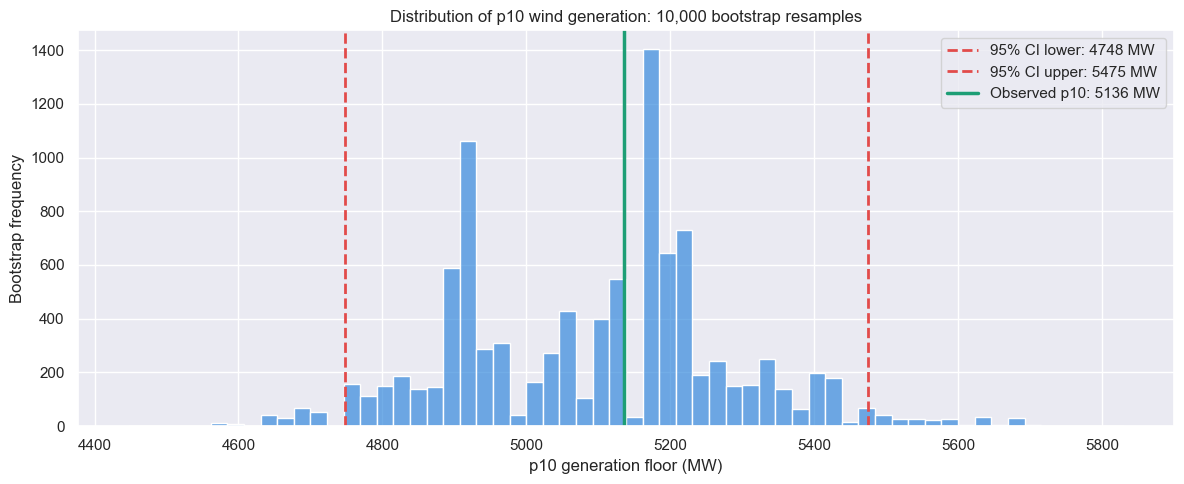

In [7]:
fig, ax = plt.subplots()
sns.histplot(p10_samples, bins=60, color="#378ADD", alpha=0.7, ax=ax)
ax.axvline(ci_low,color="#E24B4A", linewidth=2,linestyle="--", label=f"95% CI lower: {round(ci_low)} MW")
ax.axvline(ci_high,color="#E24B4A", linewidth=2,linestyle="--", label=f"95% CI upper: {round(ci_high)} MW")
ax.axvline(p10_obs,color="#1D9E75", linewidth=2.5,label=f"Observed p10: {round(p10_obs)} MW")

ax.set_xlabel("p10 generation floor (MW)")
ax.set_ylabel("Bootstrap frequency")
ax.set_title("Distribution of p10 wind generation: 10,000 bootstrap resamples")
ax.legend()

plt.tight_layout()
plt.show()

## Recommendation

**How much wind can grid operators reliably count on?**

Based on 10,000 bootstrap resamples of January 2024 actual wind generation, the p10 floor sits between **4,748 MW and 5,475 MW at 95% confidence**. We recommend using **4,748 MW as the conservative planning baseline**  i.e the lower CI bound .. meaning wind can be expected to deliver at least this much in 90% of operating hours, and we are 95% confident this floor is not a statistical artefact of a single month's sample.

**Important caveat from Analysis 1:**

This baseline assumes moderate forecast conditions. The heteroscedasticity finding shows errors grow 4.44× between low and high generation periods (R²=0.415). During high-wind events above 12,000 MW, forecast uncertainty is large enough that grid operators should not treat the WINDFOR prediction as reliable without additional reserve capacity. The 4,748 MW floor is the number to plan around .. the forecast itself should be treated with increasing scepticism above 12,000 MW.

**Summary of findings:**

| Metric | Value |
|---|---|
| MAE | 2,000 MW |
| Mean bias | +1,253 MW (systematic over-forecast) |
| P99 error | 7,016 MW |
| Reliable floor (95% CI lower) | 4,748 MW |
| Reliable floor (95% CI upper) | 5,475 MW |
| Error growth factor (low vs high wind) | 4.44× |